# Strong assumption checks via stationary bounds

From Lemma 4 of the paper, for stationary ergodic Markov chains $X, Y$ with stationary distributions $\pi_X, \pi_Y$ and substitution cost matrix $S = (c_{\text{sub}}(a,b))_{a,b\in\Sigma}$:

$$W_{\bar{d}}(\pi_X, \pi_Y) \le \gamma(X, Y) \le \pi_X^T S \pi_Y$$

This yields **sufficient conditions** (stronger than Assumption 3/4) for clustering consistency:

- **Strong separation** (sufficient for $\Delta_{\text{out}} > \Delta_{\text{in}}$):
$$\min_{k \ne k'} W_{\bar{d}}(\pi_k, \pi_{k'}) > \max_k\; \pi_k^T S \pi_k$$

- **Strong balance** (sufficient for $\Delta_{\text{out}} - \Delta_{\text{in}} > \Delta_{\text{in}} \cdot w_{\max}/w_{\min}$):
$$\min_{k \ne k'} W_{\bar{d}}(\pi_k, \pi_{k'}) > \left(1 + \frac{w_{\max}}{w_{\min}}\right) \max_k\; \pi_k^T S \pi_k$$

These conditions depend only on the **stationary distributions** and the cost matrix — no sequence simulation needed.

We sweep over $\alpha$ (Dirichlet concentration for the transition rows) and $K$ (number of clusters) and plot the probability that each strong condition holds.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed

try:
    from scipy.optimize import linprog
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

/home/ottavio/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Markov model helpers

In [2]:
def _expand_dirichlet_alpha(alpha, n_rows, n_cols, name='alpha'):
    if np.isscalar(alpha):
        if alpha <= 0:
            raise ValueError(f'{name} must be > 0')
        return np.full((n_rows, n_cols), float(alpha))
    arr = np.asarray(alpha, dtype=float)
    if arr.ndim == 1:
        if arr.shape[0] != n_cols:
            raise ValueError(f'{name} must have length {n_cols}')
        return np.tile(arr, (n_rows, 1))
    if arr.ndim == 2:
        if arr.shape != (n_rows, n_cols):
            raise ValueError(f'{name} must have shape ({n_rows}, {n_cols})')
        return arr
    raise ValueError(f'{name} must be a scalar, 1D, or 2D array')


def _context_to_index(context, n_states):
    idx = 0
    for s in context:
        idx = idx * n_states + int(s)
    return idx


def _index_to_context(idx, n_states, order):
    context = [0] * order
    for pos in range(order - 1, -1, -1):
        context[pos] = int(idx % n_states)
        idx //= n_states
    return context


def sample_markov_model(n_states, order_k, alpha, rng, alpha_init=None):
    if order_k < 1:
        raise ValueError('order_k must be >= 1')
    if n_states < 2:
        raise ValueError('n_states must be >= 2')
    n_contexts = n_states ** order_k
    trans_alpha = _expand_dirichlet_alpha(alpha, n_contexts, n_states, name='alpha')
    transitions = np.empty((n_contexts, n_states), dtype=float)
    for i in range(n_contexts):
        transitions[i] = rng.dirichlet(trans_alpha[i])
    if alpha_init is None:
        alpha_init = alpha
    if order_k == 1:
        init_alpha = _expand_dirichlet_alpha(alpha_init, 1, n_states, name='alpha_init')[0]
        init_probs = rng.dirichlet(init_alpha)
    else:
        init_alpha = np.full(n_contexts, float(alpha_init))
        init_probs = rng.dirichlet(init_alpha)
    return {
        'n_states': n_states,
        'order': order_k,
        'transitions': transitions,
        'init_probs': init_probs,
    }


def sample_stationaries_dirichlet(K, n_states, alpha, rng):
    """
    Sample K stationary distributions directly from Dirichlet(alpha).

    This bypasses transition matrix sampling entirely: each pi_k ~ Dir(alpha * 1).
    Small alpha -> peaked/heterogeneous distributions.
    Large alpha -> near-uniform distributions.
    """
    concentration = np.full(n_states, float(alpha))
    return [rng.dirichlet(concentration) for _ in range(K)]


## Stationary distributions

In [3]:
def build_context_transition_matrix(model):
    n_states = model['n_states']
    order_k = model['order']
    if order_k <= 1:
        raise ValueError('order_k must be > 1 for context transition matrix')
    n_contexts = n_states ** order_k
    Q = np.zeros((n_contexts, n_contexts), dtype=float)
    for i in range(n_contexts):
        ctx = _index_to_context(i, n_states, order_k)
        probs = model['transitions'][i]
        for a in range(n_states):
            p = probs[a]
            if p == 0:
                continue
            ctx_next = ctx[1:] + [a]
            j = _context_to_index(ctx_next, n_states)
            Q[i, j] += p
    return Q


def stationary_distribution_markov(P, init=None, tol=1e-12, max_iter=200000):
    n = P.shape[0]
    v = np.full(n, 1.0 / n) if init is None else np.asarray(init, dtype=float).reshape(-1) / np.sum(init)
    for _ in range(max_iter):
        v_next = v @ P
        if np.abs(v_next - v).sum() < tol:
            v = v_next
            break
        v = v_next
    return v / v.sum()


def stationary_symbol_distribution(model):
    n_states = model['n_states']
    order_k = model['order']
    if order_k == 1:
        return stationary_distribution_markov(model['transitions'])
    Q = build_context_transition_matrix(model)
    pi_ctx = stationary_distribution_markov(Q, init=model.get('init_probs'))
    pi_sym = np.zeros(n_states, dtype=float)
    for idx in range(Q.shape[0]):
        ctx = _index_to_context(idx, n_states, order_k)
        pi_sym[ctx[-1]] += pi_ctx[idx]
    return pi_sym / pi_sym.sum()

## Cost matrices and Wasserstein distance

In [4]:
def compute_constant_subst_matrix(n_states, cost=1.0):
    S = np.full((n_states, n_states), float(cost))
    np.fill_diagonal(S, 0.0)
    return S


def compute_random_subst_matrix(n_states, rng, low=0.5, high=2.0):
    M = rng.uniform(low, high, size=(n_states, n_states))
    S = 0.5 * (M + M.T)
    np.fill_diagonal(S, 0.0)
    return S


def choose_indel_cost(subst_cost, strategy='median_nonzero'):
    offdiag = subst_cost[~np.eye(subst_cost.shape[0], dtype=bool)]
    offdiag = offdiag[offdiag > 0]
    if offdiag.size == 0:
        return 1.0
    return float(np.median(offdiag)) if strategy == 'median_nonzero' else float(offdiag.mean())


def wasserstein_1_lp(p, q, C):
    """1-Wasserstein distance between discrete distributions p, q with cost matrix C."""
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p = p / p.sum()
    q = q / q.sum()
    n = p.size
    if SCIPY_OK:
        c = C.reshape(-1)
        A_eq = np.zeros((2 * n, n * n), dtype=float)
        for i in range(n):
            A_eq[i, i * n:(i + 1) * n] = 1.0
        for j in range(n):
            A_eq[n + j, j::n] = 1.0
        b_eq = np.concatenate([p, q])
        res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=[(0, None)] * (n * n), method='highs')
        if res.success:
            return float(res.fun)
    # Sinkhorn fallback
    eps = 1e-2
    K = np.exp(-C / eps)
    K = np.maximum(K, 1e-300)
    u = np.ones(n)
    v = np.ones(n)
    for _ in range(5000):
        u = p / np.maximum(K @ v, 1e-300)
        v = q / np.maximum(K.T @ u, 1e-300)
    Gamma = (u[:, None] * K) * v[None, :]
    return float(np.sum(Gamma * C))

## Strong assumption check (bound-based)

For $K$ models $\mathbb{P}_1, \ldots, \mathbb{P}_K$ with stationary distributions $\pi_1, \ldots, \pi_K$ and cost matrix $S$, define:

- $W_{\min} := \min_{k \ne k'} W_{\bar{d}}(\pi_k, \pi_{k'})$ (lower bound on $\Delta_{\text{out}}$)
- $\mathrm{UB}_{\max} := \max_k \pi_k^T S \pi_k$ (upper bound on $\Delta_{\text{in}}$)

**Strong separation**: $W_{\min} > \mathrm{UB}_{\max}$

**Strong balance**: $W_{\min} > (1 + w_{\max}/w_{\min}) \cdot \mathrm{UB}_{\max}$

In [5]:
def _check_strong_from_pis(pis, subst_cost, w_ratio=2.0):
    """Core computation: W_min, UB_max and strong conditions from stationary distributions."""
    K = len(pis)
    S = subst_cost

    UBs = np.array([float(pi @ S @ pi) for pi in pis])
    UB_max = float(np.max(UBs))

    W_pairs = [
        wasserstein_1_lp(pis[k], pis[kp], S)
        for k in range(K) for kp in range(k + 1, K)
    ]
    W_min = float(np.min(W_pairs)) if W_pairs else np.nan

    return {
        'pis': pis,
        'UBs': UBs,
        'UB_max': UB_max,
        'W_pairs': W_pairs,
        'W_min': W_min,
        'strong_separation': bool(W_min > UB_max),
        'strong_balance': bool(W_min > (1.0 + w_ratio) * UB_max),
    }


def check_strong_assumptions(models, subst_cost, w_ratio=2.0):
    """
    Check strong assumptions from a list of Markov chain models.
    Stationary distributions are computed from the transition matrices.
    """
    pis = [stationary_symbol_distribution(m) for m in models]
    return _check_strong_from_pis(pis, subst_cost, w_ratio=w_ratio)


## Heatmap sweep over (alpha, K)

In [6]:
def _one_point_strong(
    alpha, K, R, base_seed,
    n_states, order_k, subst_method, w_ratio,
    random_cost_low, random_cost_high,
    sample_mode,  # 'transitions' or 'stationary'
):
    """Run R repetitions for a single (alpha, K) point, return (p_separation, p_balance)."""
    ok_sep = 0
    ok_bal = 0
    for r in range(R):
        seed = base_seed + 10_000 * (int(1_000 * alpha) + 1) + 1_000 * K + r
        rng = np.random.default_rng(seed)

        if subst_method == 'constant':
            S = compute_constant_subst_matrix(n_states, cost=1.0)
        elif subst_method == 'random':
            S = compute_random_subst_matrix(n_states, rng, low=random_cost_low, high=random_cost_high)
        else:
            raise ValueError(f'Unknown subst_method: {subst_method}')

        if sample_mode == 'transitions':
            models = [
                sample_markov_model(n_states, order_k, float(alpha),
                                    np.random.default_rng(int(rng.integers(0, 2**32 - 1))))
                for _ in range(K)
            ]
            res = check_strong_assumptions(models, S, w_ratio=w_ratio)
        elif sample_mode == 'stationary':
            pis = sample_stationaries_dirichlet(K, n_states, float(alpha), rng)
            res = _check_strong_from_pis(pis, S, w_ratio=w_ratio)
        else:
            raise ValueError(f'Unknown sample_mode: {sample_mode!r}')

        ok_sep += int(res['strong_separation'])
        ok_bal += int(res['strong_balance'])

    return ok_sep / R, ok_bal / R


def sweep_strong_assumptions_heatmap(
    alphas, Ks,
    R=30,
    base_seed=123,
    n_states=5,
    order_k=1,
    subst_method='random',
    w_ratio=2.0,
    random_cost_low=0.5,
    random_cost_high=2.0,
    sample_mode='transitions',  # 'transitions' or 'stationary'
    n_jobs=-1,
):
    """
    Sweep (alpha, K) and plot two heatmaps:
      - P(strong separation holds)
      - P(strong balance holds)

    sample_mode='transitions' : sample full Markov chains, derive stationary distributions.
    sample_mode='stationary'  : sample pi_k ~ Dirichlet(alpha) directly (no transition matrix).
    """
    alphas = list(alphas)
    Ks = list(Ks)
    tasks = [(a, K) for a in alphas for K in Ks]

    results = Parallel(n_jobs=n_jobs, backend='loky', batch_size='auto', pre_dispatch='2*n_jobs')(
        delayed(_one_point_strong)(
            a, K, R, base_seed,
            n_states, order_k, subst_method, w_ratio,
            random_cost_low, random_cost_high,
            sample_mode,
        )
        for (a, K) in tasks
    )

    P_sep = np.array([r[0] for r in results], dtype=float).reshape(len(alphas), len(Ks))
    P_bal = np.array([r[1] for r in results], dtype=float).reshape(len(alphas), len(Ks))

    mode_label = 'direct Dirichlet' if sample_mode == 'stationary' else 'Markov chains'
    alpha_labels = [f'{a:.3g}' for a in alphas]
    K_labels = [str(k) for k in Ks]

    fig, axes = plt.subplots(1, 2, figsize=(max(8, 1.3 * len(Ks) + 3), max(5, 0.6 * len(alphas) + 3)))

    for ax, P, title, cbar_label in [
        (axes[0], P_sep,
         f'Strong separation\n$W_{{\\min}} > \\mathrm{{UB}}_{{\\max}}$\n({mode_label}, R={R})',
         '$P(W_{\\min} > UB_{\\max})$'),
        (axes[1], P_bal,
         f'Strong balance\n$W_{{\\min}} > (1 + w_{{\\max}}/w_{{\\min}}) \\cdot \\mathrm{{UB}}_{{\\max}}$\n({mode_label}, R={R})',
         '$P(W_{\\min} > (1+w_r) \\cdot UB_{\\max})$'),
    ]:
        im = ax.imshow(P, aspect='auto', origin='lower', vmin=0, vmax=1, cmap='viridis')
        fig.colorbar(im, ax=ax, label=cbar_label)
        ax.set_xticks(np.arange(len(Ks)))
        ax.set_xticklabels(K_labels)
        ax.set_yticks(np.arange(len(alphas)))
        ax.set_yticklabels(alpha_labels, fontsize=max(6, 9 - len(alphas) // 10))
        ax.set_xlabel('K')
        ax.set_ylabel('alpha')
        ax.set_title(title)
        if len(alphas) <= 20:
            for i in range(len(alphas)):
                for j in range(len(Ks)):
                    ax.text(j, i, f'{P[i, j]:.2f}', ha='center', va='center',
                            fontsize=8, color='white' if P[i, j] < 0.5 else 'black')

    plt.tight_layout()
    plt.show()
    return P_sep, P_bal


## Run experiment

Parameters:
- `n_states`: alphabet size $|\Sigma|$
- `order_k`: Markov order (only used when `sample_mode='transitions'`)
- `alpha`: Dirichlet concentration
  - **`sample_mode='transitions'`**: controls how peaked the transition rows are
  - **`sample_mode='stationary'`**: directly controls how peaked $\pi_k \sim \mathrm{Dir}(\alpha \cdot \mathbf{1})$ is
- `subst_method`: `'constant'` or `'random'`
- `w_ratio`: $w_{\max}/w_{\min}$ for the balance condition
- `sample_mode`: `'transitions'` (full Markov chain) or `'stationary'` (direct Dirichlet on $\pi_k$)


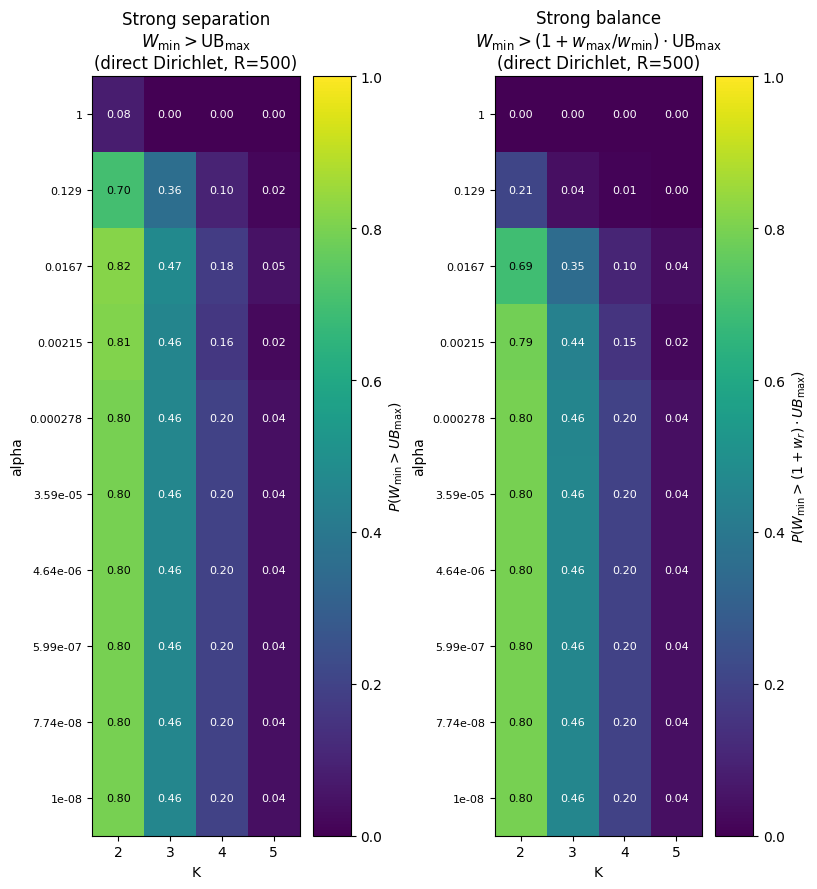

In [17]:
alphas = np.geomspace(1e-8, 1.0, num=10)
Ks = [2, 3, 4, 5]

# sample_mode='transitions' : stationaries derived from sampled Markov chains
# sample_mode='stationary'  : stationaries sampled directly from Dirichlet(alpha)
P_sep, P_bal = sweep_strong_assumptions_heatmap(
    alphas=alphas,
    Ks=Ks,
    R=500,
    base_seed=123,
    n_states=5,
    order_k=1,
    subst_method='random',
    w_ratio=2.0,
    random_cost_low=0.5,
    random_cost_high=2.0,
    sample_mode='stationary',  # <-- change to 'stationary' to sample pi_k ~ Dirichlet directly
    n_jobs=-1,
)


## Diagnostic: distribution of $W_{\min}$ and $\mathrm{UB}_{\max}$ for a fixed (alpha, K)

Useful to understand how tight the gap is.

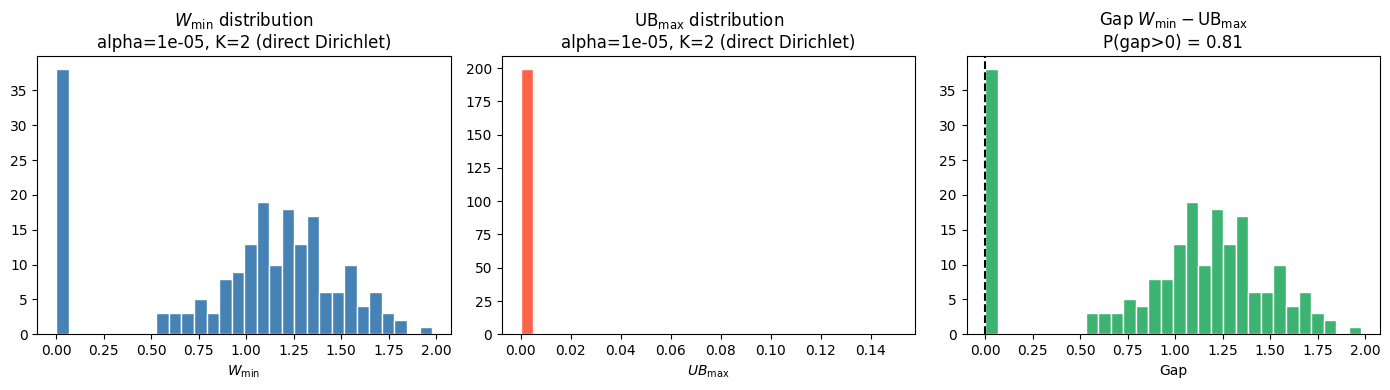

In [12]:
def diagnostic_one_point(
    alpha, K, R=200,
    base_seed=0, n_states=5, order_k=1,
    subst_method='random',
    random_cost_low=0.5, random_cost_high=2.0,
    w_ratio=2.0,
    sample_mode='stationary',  # 'transitions' or 'stationary'
):
    W_mins, UB_maxs, gaps = [], [], []
    for r in range(R):
        rng = np.random.default_rng(base_seed + r)
        if subst_method == 'constant':
            S = compute_constant_subst_matrix(n_states, cost=1.0)
        else:
            S = compute_random_subst_matrix(n_states, rng, low=random_cost_low, high=random_cost_high)

        if sample_mode == 'transitions':
            models = [
                sample_markov_model(n_states, order_k, float(alpha),
                                    np.random.default_rng(int(rng.integers(0, 2**32 - 1))))
                for _ in range(K)
            ]
            res = check_strong_assumptions(models, S, w_ratio=w_ratio)
        else:
            pis = sample_stationaries_dirichlet(K, n_states, float(alpha), rng)
            res = _check_strong_from_pis(pis, S, w_ratio=w_ratio)

        W_mins.append(res['W_min'])
        UB_maxs.append(res['UB_max'])
        gaps.append(res['W_min'] - res['UB_max'])

    W_mins = np.array(W_mins)
    UB_maxs = np.array(UB_maxs)
    gaps = np.array(gaps)
    mode_label = 'direct Dirichlet' if sample_mode == 'stationary' else 'Markov chains'

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].hist(W_mins, bins=30, color='steelblue', edgecolor='white')
    axes[0].set_title(f'$W_{{\\min}}$ distribution\nalpha={alpha}, K={K} ({mode_label})')
    axes[0].set_xlabel('$W_{\\min}$')

    axes[1].hist(UB_maxs, bins=30, color='tomato', edgecolor='white')
    axes[1].set_title(f'$\\mathrm{{UB}}_{{\\max}}$ distribution\nalpha={alpha}, K={K} ({mode_label})')
    axes[1].set_xlabel('$UB_{\\max}$')

    axes[2].hist(gaps, bins=30, color='mediumseagreen', edgecolor='white')
    axes[2].axvline(0, color='black', lw=1.5, ls='--')
    axes[2].set_title(f'Gap $W_{{\\min}} - \\mathrm{{UB}}_{{\\max}}$\nP(gap>0) = {np.mean(gaps > 0):.2f}')
    axes[2].set_xlabel('Gap')

    plt.tight_layout()
    plt.show()
    return W_mins, UB_maxs, gaps


# Example: alpha=0.05, K=3, stationary mode
W_mins, UB_maxs, gaps = diagnostic_one_point(
    alpha=1e-5, K=2, R=200,
    n_states=5, order_k=1,
    subst_method='random',
    sample_mode='stationary',  # try 'stationary' for direct Dirichlet sampling
)
